# Loan Recovery System

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')

In [10]:
df = pd.read_csv("loan-recovery.csv")
df.head()

,Borrower_ID,Age,Gender,Employment_Type,Monthly_Income,Num_Dependents,Loan_ID,Loan_Amount,Loan_Tenure,Interest_Rate,...,Collateral_Value,Outstanding_Loan_Amount,Monthly_EMI,Payment_History,Num_Missed_Payments,Days_Past_Due,Recovery_Status,Collection_Attempts,Collection_Method,Legal_Action_Taken
0,BRW_1,59,Male,Salaried,215422,0,LN_1,1445796,60,12.39,...,1.727997e+06,2.914130e+05,4856.88,On-Time,0,0,Partially Recovered,1,Settlement Offer,No
1,BRW_2,49,Female,Salaried,60893,0,LN_2,1044620,12,13.47,...,1.180032e+06,6.652042e+05,55433.68,On-Time,0,0,Fully Recovered,2,Settlement Offer,No
2,BRW_3,35,Male,Salaried,116520,1,LN_3,1923410,72,7.74,...,2.622540e+06,1.031372e+06,14324.61,Delayed,2,124,Fully Recovered,2,Legal Notice,No
3,BRW_4,63,Female,Salaried,140818,2,LN_4,1811663,36,12.23,...,1.145493e+06,2.249739e+05,6249.28,On-Time,1,56,Fully Recovered,2,Calls,No
4,BRW_5,28,Male,Salaried,76272,1,LN_5,88578,48,16.13,...,0.000000e+00,3.918989e+04,816.46,On-Time,1,69,Fully Recovered,0,Debt Collectors,No


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Borrower_ID              500 non-null    str    
 1   Age                      500 non-null    int64  
 2   Gender                   500 non-null    str    
 3   Employment_Type          500 non-null    str    
 4   Monthly_Income           500 non-null    int64  
 5   Num_Dependents           500 non-null    int64  
 6   Loan_ID                  500 non-null    str    
 7   Loan_Amount              500 non-null    int64  
 8   Loan_Tenure              500 non-null    int64  
 9   Interest_Rate            500 non-null    float64
 10  Loan_Type                500 non-null    str    
 11  Collateral_Value         500 non-null    float64
 12  Outstanding_Loan_Amount  500 non-null    float64
 13  Monthly_EMI              500 non-null    float64
 14  Payment_History          500 non-null

In [12]:
df.shape

(500, 21)

In [13]:
df.describe()

,Age,Monthly_Income,Num_Dependents,Loan_Amount,Loan_Tenure,Interest_Rate,Collateral_Value,Outstanding_Loan_Amount,Monthly_EMI,Num_Missed_Payments,Days_Past_Due,Collection_Attempts
count,500.000000,500.000000,500.000000,5.000000e+02,500.00000,500.000000,5.000000e+02,5.000000e+02,500.000000,500.000000,500.000000,500.000000
mean,43.116000,134829.920000,1.476000,1.024907e+06,46.10400,11.192820,6.032240e+05,5.627260e+05,15861.536020,1.912000,70.678000,3.000000
std,12.733217,68969.356746,1.145447,5.907556e+05,18.23706,3.775209,7.457131e+05,4.723581e+05,18709.231315,2.110252,60.211038,2.807805
min,21.000000,15207.000000,0.000000,5.413800e+04,12.00000,5.020000,0.000000e+00,1.571283e+04,261.880000,0.000000,0.000000,0.000000
25%,32.000000,76343.250000,0.000000,4.629848e+05,36.00000,7.907500,0.000000e+00,1.822072e+05,4039.097500,1.000000,4.000000,1.000000
50%,44.000000,134929.500000,1.000000,9.971240e+05,48.00000,10.915000,2.327684e+05,4.133240e+05,9330.170000,2.000000,66.500000,2.000000
75%,53.000000,193086.250000,3.000000,1.557952e+06,60.00000,14.577500,1.111106e+06,8.324787e+05,20439.485000,3.000000,122.250000,4.000000
max,64.000000,249746.000000,3.000000,1.995325e+06,72.00000,17.970000,2.744395e+06,1.932396e+06,127849.230000,12.000000,180.000000,10.000000


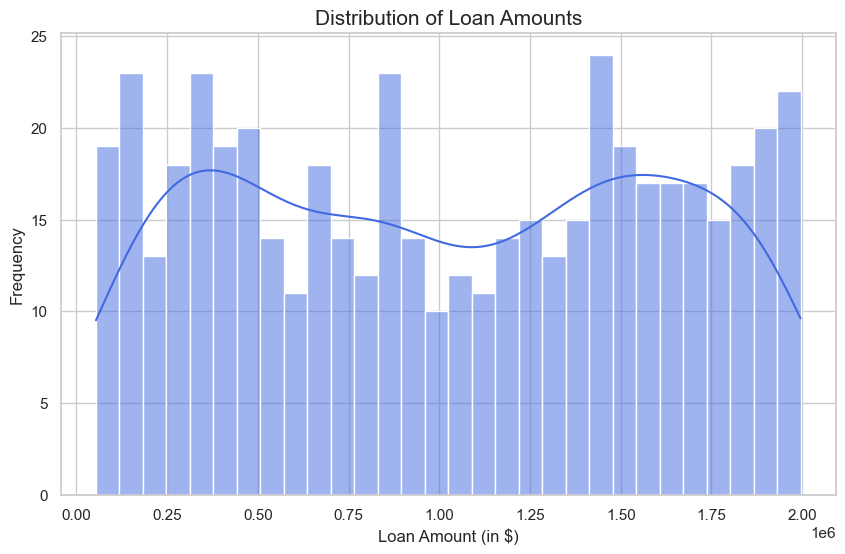

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Loan_Amount'], kde=True, color='royalblue', bins=30)
plt.title('Distribution of Loan Amounts', fontsize=15)
plt.xlabel('Loan Amount (in $)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

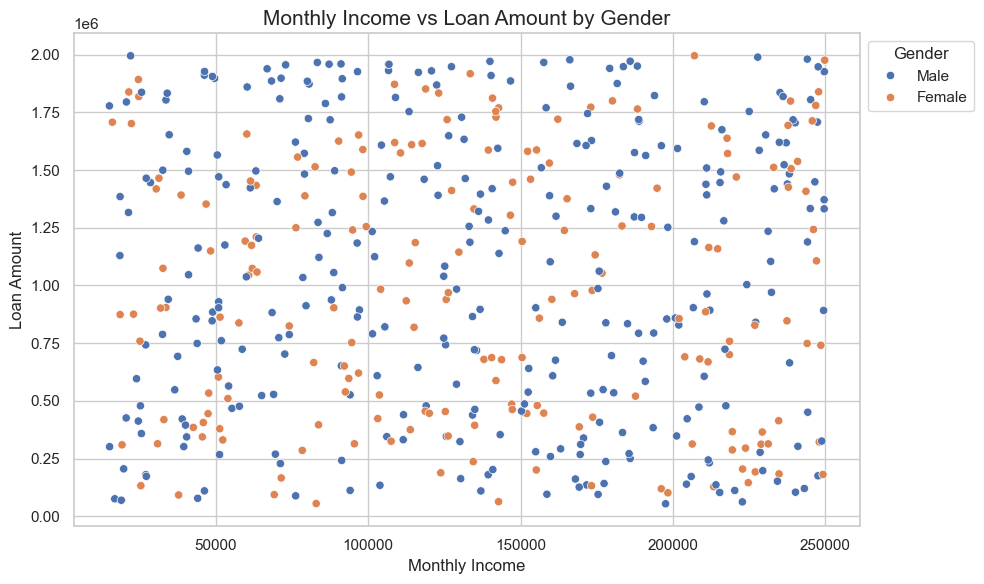

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Monthly_Income', y='Loan_Amount', hue='Gender')
plt.title('Monthly Income vs Loan Amount by Gender', fontsize=15)
plt.xlabel('Monthly Income', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.legend(title='Gender', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\WALEED TRADERS\AppData\Local\Temp\ipykernel_4992\3414456743.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette='viridis')


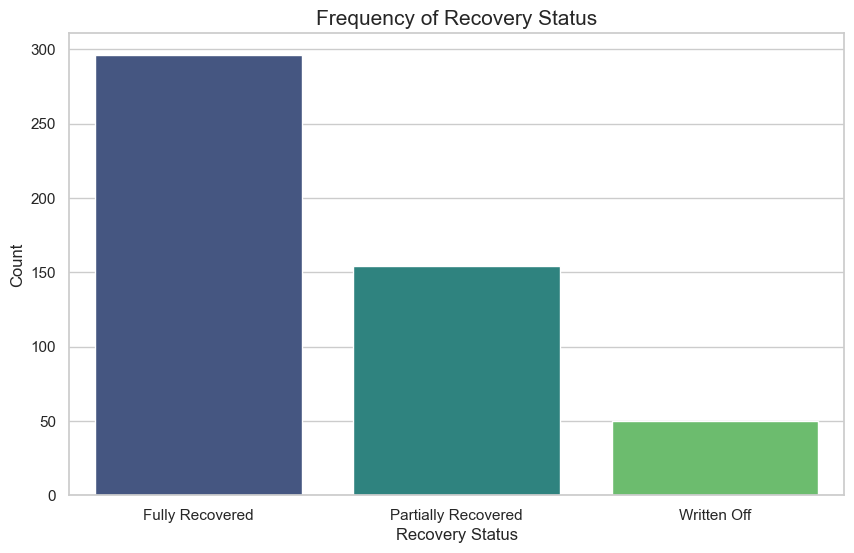

In [33]:
plt.figure(figsize=(10, 6))
status_counts = df['Recovery_Status'].value_counts()
sns.barplot(x=status_counts.index, y=status_counts.values, palette='viridis')
plt.title('Frequency of Recovery Status', fontsize=15)
plt.xlabel('Recovery Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

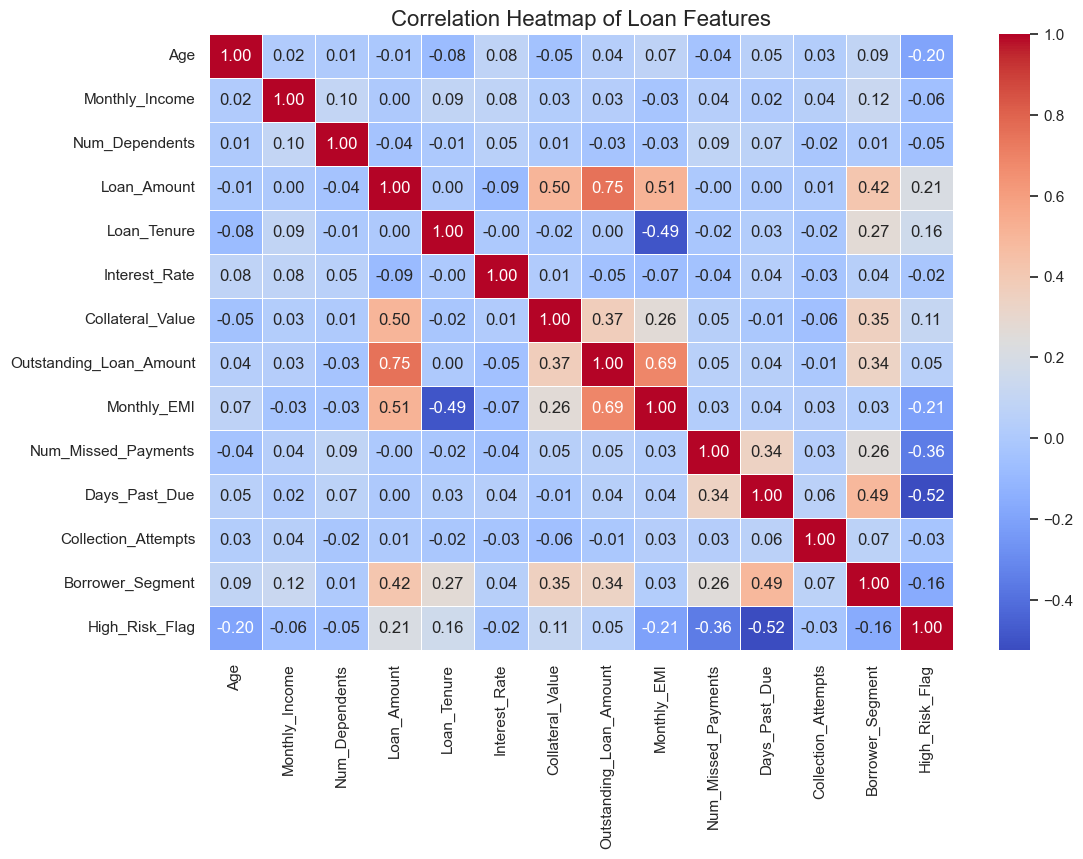

In [47]:
numerical_df = df.select_dtypes(include=['number'])

corr_matrix = numerical_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap( corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5       )
plt.title('Correlation Heatmap of Loan Features', fontsize=16)
plt.show()

## K-Means Clustering

In [37]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = ['Age', 'Monthly_Income', 'Loan_Amount', 'Loan_Tenure', 'Interest_Rate',
            'Collateral_Value', 'Outstanding_Loan_Amount', 'Monthly_EMI', 'Num_Missed_Payments', 'Days_Past_Due']

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])

In [42]:
optimal_k = 4
kmeans = KMeans(n_clusters = optimal_k, random_state=42, n_init=10)
df['Borrower_Segment'] = kmeans.fit_predict(df_scaled)

##### Giving meaningful names to our clusters
##### These names represent the 'Profile' of the borrowers in each group

In [43]:
df['Segment_Name'] = df['Borrower_Segment'].map({
    0: 'Moderate Income, High Loan Burden',
    1: 'High Income, Low Default Risk',
    2: 'Moderate Income, Medium Risk',
    3: 'High Loan, Higher Default Risk'
})

## Random Forest Classifier

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Create a binary target variable (0 or 1) based on our clusters
# 1 = High Risk 
# 0 = Lower Risk
df['High_Risk_Flag'] = df['Segment_Name'].apply(lambda x: 1 if x in ['High Loan, Higher Default Risk', 'Moderate Income, High Loan Burden'] else 0)

features = ['Age', 'Monthly_Income', 'Loan_Amount', 'Loan_Tenure', 'Interest_Rate',
            'Collateral_Value', 'Outstanding_Loan_Amount', 'Monthly_EMI', 'Num_Missed_Payments', 'Days_Past_Due']
X = df[features]
y = df['High_Risk_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [51]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

risk_scores = rf_model.predict_proba(X_test)[:, 1] 

df_test = X_test.copy()
df_test['Risk_Score'] = risk_scores

# Convert probabilities into binary 0/1 predictions using a 50% threshold
df_test['Predicted_High_Risk'] = (df_test['Risk_Score'] > 0.5).astype(int) 

df_test = df_test.merge(df[['Borrower_ID', 'Segment_Name', 'Recovery_Status', 'Collection_Method', 'Collection_Attempts', 'Legal_Action_Taken']],left_index=True, right_index=True)

### A function to map numerical risk scores to operational business actions
###### Highest risk: Use the most resource-intensive methods
###### Medium risk: Focus on negotiation and compromising to get some payment back
###### Low risk: Use low-cost, automated methods to maintain customer relationship


In [ ]:
def assign_recovery_strategy(risk_score):
    if risk_score > 0.75:
        return "Immediate legal notices & aggressive recovery attempts"
    elif 0.50 <= risk_score <= 0.75:
        return "Settlement offers & repayment plans"
    else:
        return "Automated reminders & monitoring"

df_test['Recovery_Strategy'] = df_test['Risk_Score'].apply(assign_recovery_strategy)

df_test.head()

,Age,Monthly_Income,Loan_Amount,Loan_Tenure,Interest_Rate,Collateral_Value,Outstanding_Loan_Amount,Monthly_EMI,Num_Missed_Payments,Days_Past_Due,Risk_Score,Predicted_High_Risk,Borrower_ID,Segment_Name,Recovery_Status,Collection_Method,Collection_Attempts,Legal_Action_Taken,Recovery_Strategy
436,25,156826,1510049,60,16.22,8.373402e+05,3.296001e+05,5493.34,1,179,0.42,0,BRW_437,"High Loan, Higher Default Risk",Partially Recovered,Legal Notice,7,No,Automated reminders & monitoring
448,57,33752,1803767,12,8.30,0.000000e+00,4.411477e+05,36762.31,0,0,0.64,1,BRW_449,"Moderate Income, High Loan Burden",Fully Recovered,Calls,2,No,Settlement offers & repayment plans
88,27,71503,1898058,24,12.59,1.087594e+06,4.227607e+05,17615.03,2,179,0.76,1,BRW_89,"High Loan, Higher Default Risk",Fully Recovered,Debt Collectors,3,No,Immediate legal notices & aggressive recovery ...
145,59,215641,1492181,36,15.85,1.340937e+06,1.337482e+06,37152.29,3,125,0.32,0,BRW_146,"High Income, Low Default Risk",Fully Recovered,Calls,3,No,Automated reminders & monitoring
344,52,106658,1958911,36,12.09,2.128380e+06,1.592191e+06,44227.52,0,0,0.09,0,BRW_345,"High Income, Low Default Risk",Fully Recovered,Calls,0,No,Automated reminders & monitoring
